### Imports

In [1]:
import pandas as pd
from kmer_analysis import get_kmer_frequencies, js_divergence, kl_divergence, compute_gc_content, compute_sequence_lengths, plot_gc_distribution, plot_length_distribution, levenshtein_distance, compute_min_edit_distances, plot_edit_distance_distribution
                          
from fasta_utils import load_fasta_seqs

In [1]:
from pathlib import Path
from Bio import SeqIO
import pandas as pd

def build_generated_metadata(fasta_dir):
    """
    Parse all FASTA files in a directory, compute length and GC%, 
    and save metadata as <foldername>_generated_metadata.csv
    """
    fasta_dir = Path(fasta_dir)
    assert fasta_dir.exists(), f"Folder not found: {fasta_dir}"
    
    records = []
    for fasta_file in fasta_dir.glob("*.fasta"):
        for rec in SeqIO.parse(fasta_file, "fasta"):
            seq = str(rec.seq).upper()
            length = len(seq)
            gc = (seq.count("G") + seq.count("C")) / length if length > 0 else 0
            records.append({
                "plasmid_id": rec.id,
                "length_bp": length,
                "gc_percent": gc * 100,
                "source_file": fasta_file.name
            })
    
    df = pd.DataFrame(records)
    out_file = fasta_dir.parent / f"{fasta_dir.name}_generated_metadata.csv"
    df.to_csv(out_file, index=False)
    print(f"Saved metadata for {len(df)} sequences → {out_file}")
    return df

# ─── Example Run ──────────────────────────────────────────────
meta = build_generated_metadata(
    "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_base_atg"
)
meta2 = build_generated_metadata(
    "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35_atg"
)

Saved metadata for 1000 sequences → /cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_base_atg_generated_metadata.csv
Saved metadata for 1000 sequences → /cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35_atg_generated_metadata.csv


### Load Sqequences

In [ ]:
# ─── PARAMETERS ─────────────────────────────────────────────────────────
K = 4  # k-mer size
dataset15_DIR = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset/fasta"
dataset35_DIR = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/dataset_35k/fasta"
BASE_DIR = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_basegfp2"
FT15_DIR   = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/gen_ft15kgfp_p"
FT35_DIR   = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/gen_ft35kgfp"

In [3]:
# ─── LOAD YOUR THREE POOLS ──────────────────────────────────────────────
real_seqs = load_fasta_seqs(REAL_DIR)
base_seqs = load_fasta_seqs(BASE_DIR)
ft_seqs   = load_fasta_seqs(FT_DIR)

### kmer analysis

In [4]:
# ─── COMPUTE 4-MER FREQUENCIES ─────────────────────────────────────────
real_freq = get_kmer_frequencies(real_seqs, k=K)
base_freq = get_kmer_frequencies(base_seqs, k=K)
ft_freq   = get_kmer_frequencies(ft_seqs,   k=K)

In [5]:
# ─── CALCULATE JENSEN–SHANNON DIVERGENCE ───────────────────────────────
js_base = js_divergence(real_freq, base_freq)
js_ft   = js_divergence(real_freq, ft_freq)

print(f"JS(real, base) = {js_base:.4f}")
print(f"JS(real, ft) = {js_ft:.4f}")

# ─── CALCULATE KULLBACK–LEIBLER DIVERGENCE ──────────────────────────────
kl_base = kl_divergence(real_freq, base_freq)
kl_ft   = kl_divergence(real_freq, ft_freq)

print(f"KL(real||base) = {kl_base:.4f}")
print(f"KL(real||ft) = {kl_ft:.4f}")

JS(real, base) = 0.0068
JS(real, ft) = 0.0057
KL(real||base) = 0.0271
KL(real||ft) = 0.0228


### GC analysis

In [6]:
real_gcs = compute_gc_content(real_seqs)
base_gcs = compute_gc_content(base_seqs)
ft_gcs   = compute_gc_content(ft_seqs)

real_lengths = compute_sequence_lengths(real_seqs)
base_lengths = compute_sequence_lengths(base_seqs)
ft_lengths   = compute_sequence_lengths(ft_seqs)


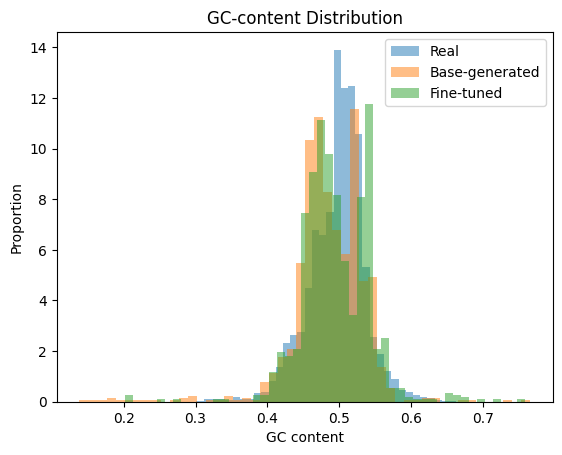

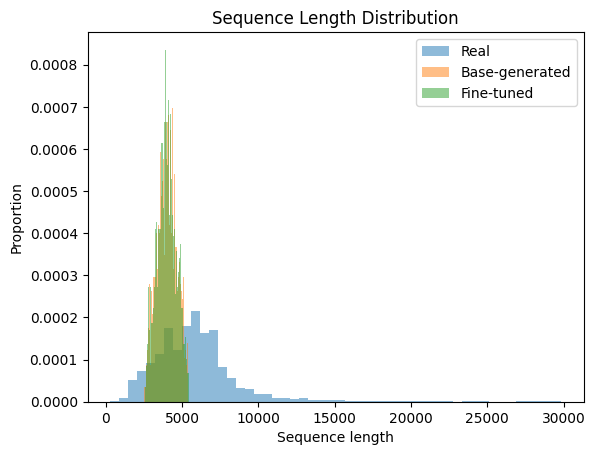

In [7]:
plot_gc_distribution(real_gcs, base_gcs, ft_gcs)
plot_length_distribution(real_lengths, base_lengths, ft_lengths)


In [8]:
# Calculate mean and median GC content and sequence lengths
real_gc_mean = pd.Series(real_gcs).mean()
real_gc_median = pd.Series(real_gcs).median()
base_gc_mean = pd.Series(base_gcs).mean()
base_gc_median = pd.Series(base_gcs).median()
ft_gc_mean = pd.Series(ft_gcs).mean()
ft_gc_median = pd.Series(ft_gcs).median() 

real_length_mean = pd.Series(real_lengths).mean()
real_length_median = pd.Series(real_lengths).median()
base_length_mean = pd.Series(base_lengths).mean()
base_length_median = pd.Series(base_lengths).median()
ft_length_mean = pd.Series(ft_lengths).mean()
ft_length_median = pd.Series(ft_lengths).median()

print(f"Real GC Mean: {real_gc_mean:.4f}, Median: {real_gc_median:.4f}")
print(f"Base GC Mean: {base_gc_mean:.4f}, Median: {base_gc_median:.4f}")
print(f"FT GC Mean: {ft_gc_mean:.4f}, Median: {ft_gc_median:.4f}")
print(f"Real Length Mean: {real_length_mean:.4f}, Median: {real_length_median:.4f}")
print(f"Base Length Mean: {base_length_mean:.4f}, Median: {base_length_median:.4f}")
print(f"FT Length Mean: {ft_length_mean:.4f}, Median: {ft_length_median:.4f}")

Real GC Mean: 0.4975, Median: 0.5014
Base GC Mean: 0.4849, Median: 0.4846
FT GC Mean: 0.4953, Median: 0.4902
Real Length Mean: 6020.4458, Median: 5681.0000
Base Length Mean: 4009.0230, Median: 4023.5000
FT Length Mean: 3986.7270, Median: 3975.0000


### Similarity reports

In [9]:
# BLAST each FT-generated FASTA separately; summarize ≥95% identity hits

from pathlib import Path
import subprocess, shutil
import pandas as pd
from IPython.display import display

# ─── CONFIG ────────────────────────────────────────────────────────────
FT_DIR  = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/gen_ft15kgfp_p")  # where your FT-generated FASTAs live
DB_NAME  = "/cs/student/projects1/aibh/2024/acunning/plasmid_db"  # base name used in `makeblastdb -out plasmid_db`
OUT_DIR  = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/blast_ft15kgfp_vs_real")        # where TSVs go
OUT_DIR.mkdir(parents=True, exist_ok=True)
THREADS  = 8
IDENTITY_THRESHOLD = 95.0
OVERWRITE = False  # set True to re-run even if TSV exists

# ─── CHECKS ────────────────────────────────────────────────────────────

# Collect .fasta and .fa files
fasta_paths = sorted(list(FT_DIR.glob("*.fasta")) + list(FT_DIR.glob("*.fa")))
print(f"Found {len(fasta_paths)} FASTA files in {FT_DIR}")

def run_blast_on_file(fp: Path) -> Path:
    """
    Run BLASTn for a single FASTA file and write a TSV with:
    qseqid, pident, length, qlen
    """
    out_tsv = OUT_DIR / f"{fp.stem}.tsv"
    if out_tsv.exists() and not OVERWRITE:
        print(f"Skipping existing: {out_tsv.name}")
        return out_tsv

    cmd = [
        "blastn",
        "-task", "megablast",
        "-query", str(fp),
        "-db", DB_NAME,
        "-out", str(out_tsv),
        "-outfmt", "6 qseqid pident length qlen",
        "-num_threads", str(THREADS),
        "-max_target_seqs", "5",
    ]
    subprocess.run(cmd, check=True)
    return out_tsv

# Run BLAST in a loop
tsv_paths = []
for i, fp in enumerate(fasta_paths, 1):
    print(f"[{i}/{len(fasta_paths)}] BLASTing {fp.name} …")
    tsv_paths.append(run_blast_on_file(fp))

def summarize_blast(tsv_files, threshold=95.0):
    """
    For each TSV, compute max %identity per query, then count how many
    queries reach the threshold. Returns per-file DF and overall totals.
    """
    total_queries = 0
    high_identity = 0
    rows = []

    for tsv in tsv_files:
        tsv = Path(tsv)
        if not tsv.exists():
            continue

        max_id_by_query = {}
        with open(tsv) as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) < 4:
                    continue
                qseqid, pident, length, qlen = parts
                pident = float(pident)
                # track maximum identity per query
                if pident > max_id_by_query.get(qseqid, 0.0):
                    max_id_by_query[qseqid] = pident

        tot = len(max_id_by_query)
        hi = sum(1 for v in max_id_by_query.values() if v >= threshold)
        pct = (hi / tot * 100.0) if tot else 0.0

        rows.append({
            "file": tsv.stem,
            "total_queries": tot,
            f">= {threshold}%": hi,
            "percent_high_id": pct
        })

        total_queries += tot
        high_identity += hi

    df = pd.DataFrame(rows).sort_values("percent_high_id", ascending=False)
    overall_pct = (high_identity / total_queries * 100.0) if total_queries else 0.0
    return df, total_queries, high_identity, overall_pct

# Summarize and display
df, tot, hi, pct = summarize_blast(tsv_paths, threshold=IDENTITY_THRESHOLD)
print(f"\nOVERALL: {hi}/{tot} sequences ≥{IDENTITY_THRESHOLD}% identity ({pct:.2f}%)")
display(df.head(25))


Found 1000 FASTA files in /cs/student/projects1/aibh/2024/acunning/Projects/Results/gen_ft15kgfp_p
[1/1000] BLASTing ft15k_generated_sequence_000.fasta …


[2/1000] BLASTing ft15k_generated_sequence_001.fasta …
[3/1000] BLASTing ft15k_generated_sequence_002.fasta …
[4/1000] BLASTing ft15k_generated_sequence_003.fasta …
[5/1000] BLASTing ft15k_generated_sequence_004.fasta …
[6/1000] BLASTing ft15k_generated_sequence_005.fasta …
[7/1000] BLASTing ft15k_generated_sequence_006.fasta …
[8/1000] BLASTing ft15k_generated_sequence_007.fasta …
[9/1000] BLASTing ft15k_generated_sequence_008.fasta …
[10/1000] BLASTing ft15k_generated_sequence_009.fasta …
[11/1000] BLASTing ft15k_generated_sequence_010.fasta …
[12/1000] BLASTing ft15k_generated_sequence_011.fasta …
[13/1000] BLASTing ft15k_generated_sequence_012.fasta …
[14/1000] BLASTing ft15k_generated_sequence_013.fasta …
[15/1000] BLASTing ft15k_generated_sequence_014.fasta …
[16/1000] BLASTing ft15k_generated_sequence_015.fasta …
[17/1000] BLASTing ft15k_generated_sequence_016.fasta …
[18/1000] BLASTing ft15k_generated_sequence_017.fasta …
[19/1000] BLASTing ft15k_generated_sequence_018.fasta …


,file,total_queries,>= 95.0%,percent_high_id
999,ft15k_generated_sequence_999,1,1,100.0
0,ft15k_generated_sequence_000,1,1,100.0
1,ft15k_generated_sequence_001,1,1,100.0
2,ft15k_generated_sequence_002,1,1,100.0
3,ft15k_generated_sequence_003,1,1,100.0
4,ft15k_generated_sequence_004,1,1,100.0
5,ft15k_generated_sequence_005,1,1,100.0
6,ft15k_generated_sequence_006,1,1,100.0
960,ft15k_generated_sequence_960,1,1,100.0
961,ft15k_generated_sequence_961,1,1,100.0


[Fine-tuned vs Real] N=1000
  Max %identity   → mean=99.70, median=99.95
  Coverage        → mean=0.553, median=0.557
  Similarity score→ mean=0.552, median=0.555
  ≥95% identity → 996/1000 (99.60%)


/tmp/ipykernel_164424/3046779961.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df["max_pident"].dropna(), labels=[f"{title_prefix}: %id"])


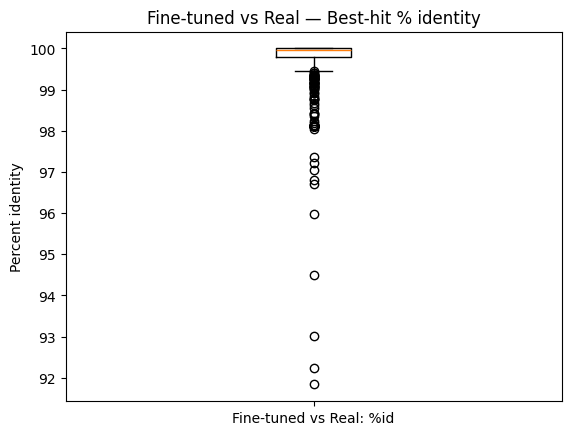

/tmp/ipykernel_164424/3046779961.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df["similarity_score"].dropna(), labels=[f"{title_prefix}: score"])


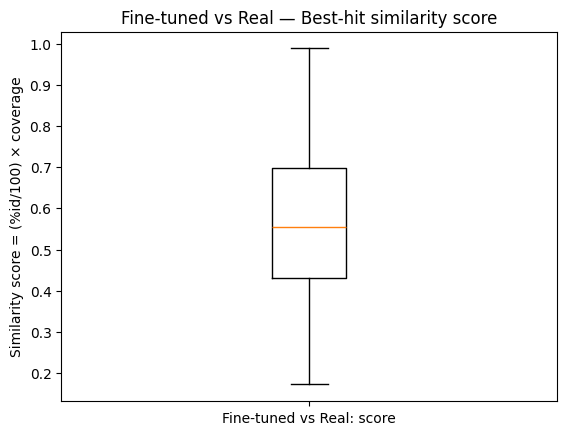

[Base vs Real] N=1000
  Max %identity   → mean=99.50, median=99.96
  Coverage        → mean=0.163, median=0.150
  Similarity score→ mean=0.163, median=0.150
  ≥95% identity → 1000/1000 (100.00%)


/tmp/ipykernel_164424/3046779961.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df["max_pident"].dropna(), labels=[f"{title_prefix}: %id"])


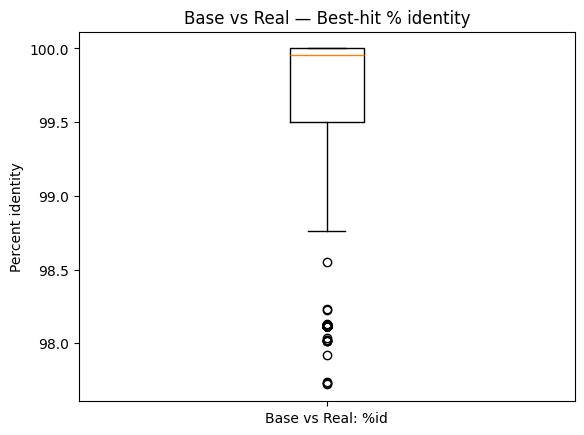

/tmp/ipykernel_164424/3046779961.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df["similarity_score"].dropna(), labels=[f"{title_prefix}: score"])


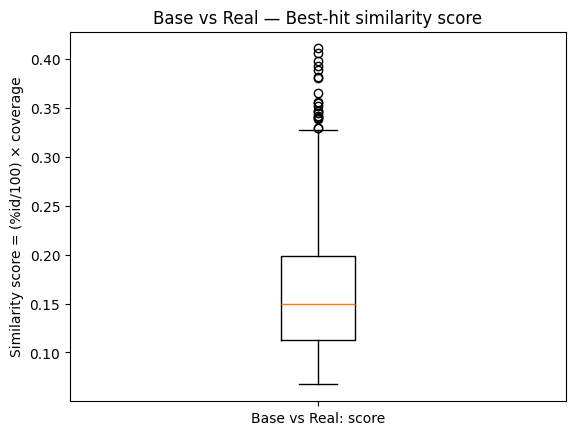

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [10]:
# Aggregate BLAST results into per-sequence similarity, summarize, and plot boxplots.
#
# Assumes you've already run BLAST and produced one or more TSVs with:
# outfmt '6 qseqid pident length qlen'
#
# This cell:
#  - Loads all TSVs from a directory
#  - Computes, for each query (generated sequence), its best hit to the training DB:
#       * max_percent_identity
#       * coverage = alignment_length / query_length
#       * similarity_score = (percent_identity/100) * coverage
#  - Prints summary stats (mean/median)
#  - Plots boxplots for identity and similarity_score
#  - Saves a CSV you can download

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ─── CONFIG ────────────────────────────────────────────────────────────
# Point this at the folder where your BLAST TSVs live (e.g., from the loop we wrote)
TSV_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/blast_ft15kgfp_vs_real")  # CHANGE ME

# Optionally, also aggregate a "base vs real" folder for comparison
TSV_DIR_BASE = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/blast_ft_vs_real_base")  # e.g., Path("/.../blast_base_vs_real") or leave as None

IDENTITY_THRESHOLD = 95.0

def load_blast_dir(tsv_dir: Path) -> pd.DataFrame:
    """
    Parse all TSVs in tsv_dir (outfmt 6: qseqid pident length qlen) and
    compute per-query best-hit statistics.
    Returns a DataFrame with columns:
      ['qseqid', 'max_pident', 'coverage', 'similarity_score', 'source_file']
    """
    rows = []
    for tsv in sorted(tsv_dir.glob("*.tsv")):
        # Track best hit per qseqid
        best = {}
        with open(tsv) as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) < 4:
                    continue
                qseqid, pident, length, qlen = parts[0], float(parts[1]), int(parts[2]), int(parts[3])
                if qlen <= 0:
                    continue
                cov = min(1.0, length / float(qlen))
                score = (pident / 100.0) * cov
                # keep the hit with highest "score"
                prev = best.get(qseqid)
                if (prev is None) or (score > prev["score"]):
                    best[qseqid] = {"pident": pident, "cov": cov, "score": score}

        for qseqid, vals in best.items():
            rows.append({
                "qseqid": qseqid,
                "max_pident": vals["pident"],
                "coverage": vals["cov"],
                "similarity_score": vals["score"],
                "source_file": tsv.name
            })

    return pd.DataFrame(rows)

def summarize_and_plot(df: pd.DataFrame, title_prefix: str):
    """
    Print summary stats and draw separate boxplots for:
      - max_pident
      - similarity_score
    """
    if df.empty:
        print(f"[{title_prefix}] No hits found.")
        return

    # Summary stats
    mean_pid = df["max_pident"].mean()
    med_pid  = df["max_pident"].median()
    mean_cov = df["coverage"].mean()
    med_cov  = df["coverage"].median()
    mean_scr = df["similarity_score"].mean()
    med_scr  = df["similarity_score"].median()

    total = len(df)
    high  = (df["max_pident"] >= IDENTITY_THRESHOLD).sum()
    pct   = high / total * 100.0

    print(f"[{title_prefix}] N={total}")
    print(f"  Max %identity   → mean={mean_pid:.2f}, median={med_pid:.2f}")
    print(f"  Coverage        → mean={mean_cov:.3f}, median={med_cov:.3f}")
    print(f"  Similarity score→ mean={mean_scr:.3f}, median={med_scr:.3f}")
    print(f"  ≥{IDENTITY_THRESHOLD:.0f}% identity → {high}/{total} ({pct:.2f}%)")

    # Boxplot of %identity
    plt.figure()
    plt.boxplot(df["max_pident"].dropna(), labels=[f"{title_prefix}: %id"])
    plt.ylabel("Percent identity")
    plt.title(f"{title_prefix} — Best-hit % identity")
    plt.show()

    # Boxplot of similarity score
    plt.figure()
    plt.boxplot(df["similarity_score"].dropna(), labels=[f"{title_prefix}: score"])
    plt.ylabel("Similarity score = (%id/100) × coverage")
    plt.title(f"{title_prefix} — Best-hit similarity score")
    plt.show()

# ─── LOAD, SUMMARIZE, PLOT ────────────────────────────────────────────
df_ft = load_blast_dir(TSV_DIR)
summarize_and_plot(df_ft, "Fine-tuned vs Real")

# Optional: compare Base vs Real similarly (if TSV_DIR_BASE set)
if TSV_DIR_BASE:
    df_base = load_blast_dir(TSV_DIR_BASE)
    summarize_and_plot(df_base, "Base vs Real")

# Save CSVs for downstream analysis
out_ft_csv = "/mnt/data/ft_similarity_summary.csv"
df_ft.to_csv(out_ft_csv, index=False)
print(f"Saved FT summary: {out_ft_csv}")

if TSV_DIR_BASE:
    out_base_csv = "/mnt/data/base_similarity_summary.csv"
    df_base.to_csv(out_base_csv, index=False)
    print(f"Saved Base summary: {out_base_csv}")


### Create Summary table

In [ ]:


# ─── BUILD SUMMARY TABLE ────────────────────────────────────────────────
df = pd.DataFrame({
    "Model": ["Base Generated", "Fine-Tuned Generated"],
    f"JS Divergence (k={K})": [js_base, js_ft]
})

# ─── DISPLAY INTERACTIVE TABLE ─────────────────────────────────────────
df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
).set_caption(f"Jensen–Shannon Divergence of k-mer Frequencies (k={K})")

display(df)


In [11]:
from pathlib import Path
import subprocess
import pandas as pd

# Paths
STRICT_CSV = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/strict_qc_passed.csv")
STRICT_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/qc_passed/ft_15STRICTgfp_passed")
DB_NAME = "/cs/student/projects1/aibh/2024/acunning/plasmid_db"
OUT_DIR = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/blast_strict_vs_real")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load list of strict-passed sequences
strict_df = pd.read_csv(STRICT_CSV)
strict_ids = [pid.replace("_pLann", "") for pid in strict_df['plasmid_id']]

def get_blast_similarity(fasta_path):
    """Run BLAST and return best similarity score (pident/100 * coverage)"""
    out_tsv = OUT_DIR / f"{fasta_path.stem}_blast.tsv"
    
    # Run BLAST
    cmd = [
        "blastn",
        "-task", "megablast",
        "-query", str(fasta_path),
        "-db", DB_NAME,
        "-out", str(out_tsv),
        "-outfmt", "6 qseqid pident length qlen",
        "-num_threads", "8",
        "-max_target_seqs", "5"
    ]
    subprocess.run(cmd, check=True)
    
    # Parse results
    best_score = 0
    with open(out_tsv) as f:
        for line in f:
            qseqid, pident, length, qlen = line.strip().split()
            pident = float(pident)
            coverage = min(1.0, int(length) / float(qlen))
            score = (pident / 100.0) * coverage
            best_score = max(best_score, score)
    
    return best_score

# Get similarity scores for each sequence
results = []
for seq_id in strict_ids:
    fasta_path = STRICT_DIR / f"{seq_id}.fasta"
    if fasta_path.exists():
        score = get_blast_similarity(fasta_path)
        results.append({
            'sequence_id': seq_id,
            'similarity_score': score
        })

# Create and display results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('similarity_score', ascending=False)

print("Similarity Scores for Strict QC-Passed Sequences:")
print(f"Mean similarity: {results_df['similarity_score'].mean():.3f}")
print(f"Median similarity: {results_df['similarity_score'].median():.3f}")
print("\nTop matches:")
display(results_df)

# Save results
out_csv = OUT_DIR / "strict_similarity_scores.csv"
results_df.to_csv(out_csv, index=False)
print(f"\nSaved detailed results to: {out_csv}")

Similarity Scores for Strict QC-Passed Sequences:
Mean similarity: 0.552
Median similarity: 0.532

Top matches:


,sequence_id,similarity_score
28,ft15k_generated_sequence_975,0.757297
10,ft15k_generated_sequence_611,0.753982
14,ft15k_generated_sequence_744,0.739726
12,ft15k_generated_sequence_653,0.731627
2,ft15k_generated_sequence_157,0.714744
18,ft15k_generated_sequence_814,0.687291
29,ft15k_generated_sequence_987,0.680140
24,ft15k_generated_sequence_886,0.654724
11,ft15k_generated_sequence_625,0.626850
26,ft15k_generated_sequence_941,0.621481



Saved detailed results to: /cs/student/projects1/aibh/2024/acunning/Projects/Results/blast_strict_vs_real/strict_similarity_scores.csv
